# CleanAir AI — Notebook 05: Advanced Intelligence Layers

This notebook builds the advanced intelligence layer on top of the AQI forecasting model.

## Inputs

- `data/processed/station_source_attributed.csv`
- `data/processed/test_predictions_with_uncertainty.csv`
- `outputs/final_aqi_model_metrics.json`

## Main tasks

1. Load source-attributed station data.
2. Load forecast predictions from Notebook 04.
3. Merge latest prediction per station.
4. Build advanced pollution intelligence scores:
   - Satellite aerosol proxy score
   - Dispersion index
   - Health exposure risk score
   - Forecasted hotspot risk score
   - Intervention urgency score
5. Rank stations by priority.
6. Generate recommended interventions.
7. Save station-level and city-level intelligence outputs.
8. Create visual and map-ready outputs.

In [2]:
from pathlib import Path
from datetime import datetime
import json
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"

for folder in [
    PROCESSED_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed folder:", PROCESSED_DIR)
print("Outputs folder:", OUTPUTS_DIR)
print("Reports folder:", REPORTS_DIR)

Project root: C:\Users\Lenovo\Desktop\CleanAir_AI
Processed folder: C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed
Outputs folder: C:\Users\Lenovo\Desktop\CleanAir_AI\outputs
Reports folder: C:\Users\Lenovo\Desktop\CleanAir_AI\reports


In [4]:
SOURCE_ATTRIBUTED_PATH = PROCESSED_DIR / "station_source_attributed.csv"

if not SOURCE_ATTRIBUTED_PATH.exists():
    raise FileNotFoundError(
        f"Missing file: {SOURCE_ATTRIBUTED_PATH}. Run Notebook 03 first."
    )

station_df = pd.read_csv(SOURCE_ATTRIBUTED_PATH)

print("Loaded source-attributed station data.")
print("Shape:", station_df.shape)

display(station_df.head())

Loaded source-attributed station data.
Shape: (500, 50)


,station_id,station_name,city,state,lat,lon,timestamp,PM2.5,PM10,NO2,...,primary_pollution_source,primary_source_score,secondary_source_score,source_score_gap,source_attribution_confidence,source_attribution_confidence_category,source_evidence,landuse_source_alignment,recommended_intervention,notebook_03_processed_time
0,andhra_pradesh__amaravati__secretariat_amarava...,"Secretariat, Amaravati - APPCB",Amaravati,Andhra Pradesh,16.515083,80.518167,2026-07-16 05:00:00,54.0,172.0,32.0,...,Construction / road dust,38.40,34.56,3.84,28.03,Low confidence,PM10-heavy particulate pattern; road dust / co...,Partially aligned,High priority: Prioritize road dust suppressio...,2026-07-16 10:55:13
1,andhra_pradesh__anantapur__gulzarpet_anantapur...,"Gulzarpet, Anantapur - APPCB",Anantapur,Andhra Pradesh,14.675886,77.593027,2026-07-16 05:00:00,85.0,76.0,16.0,...,Biomass / fine-particle combustion,35.37,29.84,5.53,26.42,Low confidence,PM2.5-heavy fine-particle pattern; CO and stag...,Partially aligned,High priority: Prioritize open-burning control...,2026-07-16 10:55:13
2,andhra_pradesh__chittoor__gangineni_cheruvu_ch...,"Gangineni Cheruvu, Chittoor - APPCB",Chittoor,Andhra Pradesh,13.204880,79.097889,2026-07-16 05:00:00,70.0,64.0,31.0,...,Biomass / fine-particle combustion,36.34,33.72,2.62,26.22,Low confidence,PM2.5-heavy fine-particle pattern; CO and stag...,Partially aligned,High priority: Prioritize open-burning control...,2026-07-16 10:55:13
3,andhra_pradesh__eluru__district_court_eluru_appcb,"District Court, Eluru - APPCB",Eluru,Andhra Pradesh,16.711754,81.092095,2026-07-16 05:00:00,49.0,49.0,22.0,...,Biomass / fine-particle combustion,34.09,26.13,7.96,26.25,Low confidence,PM2.5-heavy fine-particle pattern; CO and stag...,Partially aligned,High priority: Prioritize open-burning control...,2026-07-16 10:55:13
4,andhra_pradesh__guntur__rajendra_nagar_north_g...,"Rajendra Nagar North, Guntur - APPCB",Guntur,Andhra Pradesh,16.316553,80.413302,2026-07-16 05:00:00,52.0,52.0,42.0,...,Photochemical smog,32.25,31.11,1.14,22.92,Low confidence,O3 and temperature-related signal; urban photo...,Partially aligned,High priority: Prioritize NOx/VOC precursor co...,2026-07-16 10:55:13


In [5]:
PREDICTIONS_PATH = PROCESSED_DIR / "test_predictions_with_uncertainty.csv"

if not PREDICTIONS_PATH.exists():
    raise FileNotFoundError(
        f"Missing file: {PREDICTIONS_PATH}. Run Notebook 04 first."
    )

predictions_df = pd.read_csv(PREDICTIONS_PATH)

print("Loaded forecast predictions.")
print("Shape:", predictions_df.shape)

display(predictions_df.head())

Loaded forecast predictions.
Shape: (1032, 16)


,station_id,station_name,city,state,timestamp,reported_aqi,target_aqi_next,best_model,predicted_aqi_next,residual,absolute_error,predicted_aqi_p10,predicted_aqi_p50,predicted_aqi_p90,actual_category,predicted_category
0,bihar__patna__drm_office_danapur_patna_bspcb,"DRM Office Danapur, Patna - BSPCB",Patna,Bihar,2026-07-16 02:00:00,431.51,431.51,Random Forest,431.116411,0.393589,0.393589,380.542681,431.116411,481.690141,Severe,Severe
1,delhi__delhi__nsut_jaffarpur_delhi_dpcc,"NSUT Jaffarpur, Delhi - DPCC",Delhi,Delhi,2026-07-16 02:00:00,487.55,481.32,Random Forest,488.500398,-7.180398,7.180398,437.926668,488.500398,500.000000,Severe,Severe
2,karnataka__shivamogga__vinoba_nagara_shivamogg...,"Vinoba Nagara, Shivamogga - KSPCB",Shivamogga,Karnataka,2026-07-16 02:00:00,358.99,364.85,Random Forest,357.633139,7.216861,7.216861,307.059409,357.633139,408.206869,Very Poor,Very Poor
3,delhi__delhi__sirifort_delhi_cpcb,"Sirifort, Delhi - CPCB",Delhi,Delhi,2026-07-16 02:00:00,312.13,323.85,Random Forest,315.536541,8.313459,8.313459,264.962811,315.536541,366.110271,Very Poor,Very Poor
4,rajasthan__churu__subash_chowk_churu_rspcb,"Subash Chowk, Churu - RSPCB",Churu,Rajasthan,2026-07-16 02:00:00,323.85,323.85,Random Forest,321.793236,2.056764,2.056764,271.219506,321.793236,372.366966,Very Poor,Very Poor


In [6]:
FINAL_MODEL_METRICS_PATH = OUTPUTS_DIR / "final_aqi_model_metrics.json"

if FINAL_MODEL_METRICS_PATH.exists():
    with open(FINAL_MODEL_METRICS_PATH, "r", encoding="utf-8") as file:
        model_metrics = json.load(file)
else:
    model_metrics = {}

print("Loaded model metrics.")

if model_metrics:
    print("Best model:", model_metrics.get("best_model"))
    print("Best metrics:", model_metrics.get("best_metrics"))
else:
    print("Model metrics file not found. Continuing without it.")

Loaded model metrics.
Best model: Random Forest
Best metrics: {'model': 'Random Forest', 'mae': 14.5002, 'rmse': 39.879, 'r2': 0.8718, 'improvement_over_persistence_percent': 4.22}


In [7]:
def find_first_existing_column(df, candidates):
    lower_column_map = {
        str(col).lower().strip(): col
        for col in df.columns
    }

    for candidate in candidates:
        if candidate in df.columns:
            return candidate

        key = str(candidate).lower().strip()

        if key in lower_column_map:
            return lower_column_map[key]

    return None


def to_numeric_series(df, column_name, default_value=np.nan):
    if column_name is None or column_name not in df.columns:
        return pd.Series(default_value, index=df.index)

    return pd.to_numeric(df[column_name], errors="coerce")


def normalize_0_100(series):
    series = pd.to_numeric(series, errors="coerce")
    series = series.replace([np.inf, -np.inf], np.nan)

    if series.notna().sum() == 0:
        return pd.Series(0, index=series.index)

    lower = series.quantile(0.01)
    upper = series.quantile(0.99)

    clipped = series.clip(lower=lower, upper=upper)

    minimum = clipped.min()
    maximum = clipped.max()

    if pd.isna(minimum) or pd.isna(maximum) or maximum == minimum:
        return pd.Series(0, index=series.index)

    normalized = ((clipped - minimum) / (maximum - minimum)) * 100

    return normalized.fillna(0)


def get_aqi_category(aqi):
    if pd.isna(aqi):
        return "Unknown"

    aqi = float(aqi)

    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"


def get_score_level(score):
    if pd.isna(score):
        return "Unknown"

    score = float(score)

    if score >= 80:
        return "Critical"
    elif score >= 60:
        return "High"
    elif score >= 40:
        return "Moderate"
    elif score >= 20:
        return "Low"
    else:
        return "Minimal"


print("Helper functions ready.")

Helper functions ready.


In [8]:
aqi_column = find_first_existing_column(
    station_df,
    [
        "reported_aqi",
        "aqi",
        "AQI"
    ]
)

pm25_column = find_first_existing_column(
    station_df,
    [
        "PM2.5",
        "PM25",
        "pm25",
        "pm2_5"
    ]
)

pm10_column = find_first_existing_column(
    station_df,
    [
        "PM10",
        "pm10"
    ]
)

no2_column = find_first_existing_column(
    station_df,
    [
        "NO2",
        "no2"
    ]
)

co_column = find_first_existing_column(
    station_df,
    [
        "CO",
        "co"
    ]
)

o3_column = find_first_existing_column(
    station_df,
    [
        "O3",
        "o3"
    ]
)

wind_column = find_first_existing_column(
    station_df,
    [
        "wind_speed_10m",
        "wind_speed"
    ]
)

humidity_column = find_first_existing_column(
    station_df,
    [
        "relative_humidity_2m",
        "humidity"
    ]
)

rain_column = find_first_existing_column(
    station_df,
    [
        "rain",
        "precipitation"
    ]
)

cloud_column = find_first_existing_column(
    station_df,
    [
        "cloud_cover"
    ]
)

weather_trapping_column = find_first_existing_column(
    station_df,
    [
        "weather_trapping_score"
    ]
)

environmental_risk_column = find_first_existing_column(
    station_df,
    [
        "environmental_risk_score"
    ]
)

print("Detected columns:")
print("AQI:", aqi_column)
print("PM2.5:", pm25_column)
print("PM10:", pm10_column)
print("NO2:", no2_column)
print("CO:", co_column)
print("O3:", o3_column)
print("Wind:", wind_column)
print("Humidity:", humidity_column)
print("Rain:", rain_column)
print("Cloud:", cloud_column)
print("Weather trapping:", weather_trapping_column)
print("Environmental risk:", environmental_risk_column)

if aqi_column is None:
    raise KeyError("No AQI column found in station_source_attributed.csv")

Detected columns:
AQI: reported_aqi
PM2.5: PM2.5
PM10: PM10
NO2: NO2
CO: CO
O3: O3
Wind: wind_speed_10m
Humidity: relative_humidity_2m
Rain: rain
Cloud: cloud_cover
Weather trapping: weather_trapping_score
Environmental risk: environmental_risk_score


In [9]:
predictions_df["timestamp"] = pd.to_datetime(
    predictions_df["timestamp"],
    errors="coerce"
)

predictions_df = predictions_df.sort_values(
    ["station_id", "timestamp"]
).reset_index(drop=True)

latest_predictions = (
    predictions_df
    .dropna(subset=["station_id"])
    .groupby("station_id", as_index=False)
    .tail(1)
)

prediction_columns = [
    "station_id",
    "timestamp",
    "predicted_aqi_next",
    "predicted_aqi_p10",
    "predicted_aqi_p50",
    "predicted_aqi_p90",
    "predicted_category"
]

available_prediction_columns = [
    col for col in prediction_columns
    if col in latest_predictions.columns
]

latest_predictions = latest_predictions[available_prediction_columns].copy()

latest_predictions = latest_predictions.rename(
    columns={
        "timestamp": "forecast_reference_timestamp",
        "predicted_aqi_next": "forecast_aqi_next",
        "predicted_aqi_p10": "forecast_aqi_p10",
        "predicted_aqi_p50": "forecast_aqi_p50",
        "predicted_aqi_p90": "forecast_aqi_p90",
        "predicted_category": "forecast_category"
    }
)

advanced_df = station_df.merge(
    latest_predictions,
    on="station_id",
    how="left"
)

advanced_df["current_aqi"] = to_numeric_series(
    advanced_df,
    aqi_column
)

advanced_df["forecast_aqi_next"] = pd.to_numeric(
    advanced_df.get("forecast_aqi_next"),
    errors="coerce"
)

advanced_df["forecast_aqi_next"] = advanced_df["forecast_aqi_next"].fillna(
    advanced_df["current_aqi"]
)

for col in [
    "forecast_aqi_p10",
    "forecast_aqi_p50",
    "forecast_aqi_p90"
]:
    if col not in advanced_df.columns:
        advanced_df[col] = np.nan

    advanced_df[col] = pd.to_numeric(
        advanced_df[col],
        errors="coerce"
    ).fillna(advanced_df["forecast_aqi_next"])

advanced_df["current_aqi_category"] = advanced_df["current_aqi"].apply(get_aqi_category)
advanced_df["forecast_aqi_category"] = advanced_df["forecast_aqi_next"].apply(get_aqi_category)

advanced_df["forecast_aqi_change"] = (
    advanced_df["forecast_aqi_next"] - advanced_df["current_aqi"]
)

advanced_df["forecast_trend"] = np.select(
    [
        advanced_df["forecast_aqi_change"] >= 25,
        advanced_df["forecast_aqi_change"] <= -25
    ],
    [
        "Increasing",
        "Decreasing"
    ],
    default="Stable"
)

print("Merged latest predictions with station data.")
print("Shape:", advanced_df.shape)

display(
    advanced_df[
        [
            "state",
            "city",
            "station_name",
            "current_aqi",
            "current_aqi_category",
            "forecast_aqi_next",
            "forecast_aqi_category",
            "forecast_aqi_change",
            "forecast_trend"
        ]
    ].head(20)
)

Merged latest predictions with station data.
Shape: (500, 61)


,state,city,station_name,current_aqi,current_aqi_category,forecast_aqi_next,forecast_aqi_category,forecast_aqi_change,forecast_trend
0,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",500.00,Severe,465.739427,Severe,-34.260573,Decreasing
1,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",329.70,Very Poor,333.989192,Very Poor,4.289192,Stable
2,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",323.85,Very Poor,319.248711,Very Poor,-4.601289,Stable
3,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",306.27,Very Poor,324.354062,Very Poor,18.084062,Stable
4,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",271.30,Poor,302.897314,Very Poor,31.597314,Increasing
5,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",364.85,Very Poor,376.069953,Very Poor,11.219953,Stable
6,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",174.94,Moderate,202.273559,Poor,27.333559,Increasing
7,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",317.99,Very Poor,343.043711,Very Poor,25.053711,Increasing
8,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",412.83,Severe,417.500222,Severe,4.670222,Stable
9,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",353.14,Very Poor,365.435188,Very Poor,12.295188,Stable


In [10]:
pm25_norm = normalize_0_100(
    to_numeric_series(advanced_df, pm25_column)
)

pm10_norm = normalize_0_100(
    to_numeric_series(advanced_df, pm10_column)
)

no2_norm = normalize_0_100(
    to_numeric_series(advanced_df, no2_column)
)

co_norm = normalize_0_100(
    to_numeric_series(advanced_df, co_column)
)

o3_norm = normalize_0_100(
    to_numeric_series(advanced_df, o3_column)
)

cloud_norm = normalize_0_100(
    to_numeric_series(advanced_df, cloud_column)
)

humidity_norm = normalize_0_100(
    to_numeric_series(advanced_df, humidity_column)
)

advanced_df["satellite_aerosol_proxy_score"] = (
    0.35 * pm25_norm
    + 0.25 * pm10_norm
    + 0.15 * no2_norm
    + 0.10 * co_norm
    + 0.05 * o3_norm
    + 0.05 * cloud_norm
    + 0.05 * humidity_norm
).round(2)

advanced_df["satellite_aerosol_proxy_category"] = advanced_df[
    "satellite_aerosol_proxy_score"
].apply(get_score_level)

advanced_df["satellite_data_source"] = (
    "Proxy derived from ground pollutants and meteorology; not direct satellite imagery"
)

print("Satellite aerosol proxy score created.")

display(
    advanced_df[
        [
            "state",
            "city",
            "station_name",
            "satellite_aerosol_proxy_score",
            "satellite_aerosol_proxy_category",
            "satellite_data_source"
        ]
    ].head(20)
)

Satellite aerosol proxy score created.


,state,city,station_name,satellite_aerosol_proxy_score,satellite_aerosol_proxy_category,satellite_data_source
0,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",45.83,Moderate,Proxy derived from ground pollutants and meteo...
1,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",32.28,Low,Proxy derived from ground pollutants and meteo...
2,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",30.85,Low,Proxy derived from ground pollutants and meteo...
3,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",23.11,Low,Proxy derived from ground pollutants and meteo...
4,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",27.87,Low,Proxy derived from ground pollutants and meteo...
5,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",25.72,Low,Proxy derived from ground pollutants and meteo...
6,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",22.47,Low,Proxy derived from ground pollutants and meteo...
7,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",23.92,Low,Proxy derived from ground pollutants and meteo...
8,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",29.59,Low,Proxy derived from ground pollutants and meteo...
9,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",28.18,Low,Proxy derived from ground pollutants and meteo...


In [11]:
wind = to_numeric_series(advanced_df, wind_column).fillna(
    to_numeric_series(advanced_df, wind_column).median()
)

wind_norm = normalize_0_100(wind)

low_wind_risk = 100 - wind_norm

humidity_risk = normalize_0_100(
    to_numeric_series(advanced_df, humidity_column)
)

cloud_risk = normalize_0_100(
    to_numeric_series(advanced_df, cloud_column)
)

rain = to_numeric_series(advanced_df, rain_column).fillna(0)

rain_norm = normalize_0_100(rain)

no_rain_risk = 100 - rain_norm

weather_trapping_norm = normalize_0_100(
    to_numeric_series(advanced_df, weather_trapping_column)
)

advanced_df["dispersion_index"] = (
    0.35 * low_wind_risk
    + 0.25 * weather_trapping_norm
    + 0.15 * humidity_risk
    + 0.15 * cloud_risk
    + 0.10 * no_rain_risk
).round(2)

advanced_df["dispersion_category"] = advanced_df["dispersion_index"].apply(
    get_score_level
)

print("Dispersion index created.")
print("Higher value means poorer pollutant dispersion.")

display(
    advanced_df[
        [
            "state",
            "city",
            "station_name",
            "dispersion_index",
            "dispersion_category"
        ]
    ].head(20)
)

Dispersion index created.
Higher value means poorer pollutant dispersion.


,state,city,station_name,dispersion_index,dispersion_category
0,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",40.15,Moderate
1,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",36.18,Low
2,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",49.15,Moderate
3,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",55.93,Moderate
4,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",43.34,Moderate
5,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",34.19,Low
6,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",20.84,Low
7,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",30.50,Low
8,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",32.24,Low
9,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",45.57,Moderate


In [12]:
current_aqi_norm = normalize_0_100(
    advanced_df["current_aqi"]
)

forecast_aqi_norm = normalize_0_100(
    advanced_df["forecast_aqi_next"]
)

environmental_risk_norm = normalize_0_100(
    to_numeric_series(advanced_df, environmental_risk_column)
)

satellite_proxy_norm = normalize_0_100(
    advanced_df["satellite_aerosol_proxy_score"]
)

dispersion_norm = normalize_0_100(
    advanced_df["dispersion_index"]
)

pm25_health_norm = normalize_0_100(
    to_numeric_series(advanced_df, pm25_column)
)

advanced_df["health_exposure_risk_score"] = (
    0.30 * current_aqi_norm
    + 0.25 * forecast_aqi_norm
    + 0.20 * pm25_health_norm
    + 0.10 * dispersion_norm
    + 0.10 * satellite_proxy_norm
    + 0.05 * environmental_risk_norm
).round(2)

advanced_df["health_exposure_risk_category"] = advanced_df[
    "health_exposure_risk_score"
].apply(get_score_level)

print("Health exposure risk score created.")

display(
    advanced_df[
        [
            "state",
            "city",
            "station_name",
            "current_aqi",
            "forecast_aqi_next",
            "health_exposure_risk_score",
            "health_exposure_risk_category"
        ]
    ].head(20)
)

Health exposure risk score created.


,state,city,station_name,current_aqi,forecast_aqi_next,health_exposure_risk_score,health_exposure_risk_category
0,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",500.00,465.739427,70.21,High
1,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",329.70,333.989192,49.71,Moderate
2,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",323.85,319.248711,48.69,Moderate
3,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",306.27,324.354062,45.32,Moderate
4,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",271.30,302.897314,40.67,Moderate
5,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",364.85,376.069953,49.87,Moderate
6,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",174.94,202.273559,23.88,Low
7,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",317.99,343.043711,43.89,Moderate
8,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",412.83,417.500222,56.54,Moderate
9,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",353.14,365.435188,50.93,Moderate


In [13]:
forecast_change_norm = normalize_0_100(
    advanced_df["forecast_aqi_change"].clip(lower=0)
)

advanced_df["forecast_hotspot_risk_score"] = (
    0.40 * forecast_aqi_norm
    + 0.20 * current_aqi_norm
    + 0.15 * dispersion_norm
    + 0.15 * satellite_proxy_norm
    + 0.10 * forecast_change_norm
).round(2)

advanced_df["forecast_hotspot_risk_category"] = advanced_df[
    "forecast_hotspot_risk_score"
].apply(get_score_level)

advanced_df["intervention_urgency_score"] = (
    0.30 * advanced_df["forecast_hotspot_risk_score"]
    + 0.30 * advanced_df["health_exposure_risk_score"]
    + 0.20 * advanced_df["dispersion_index"]
    + 0.20 * advanced_df["satellite_aerosol_proxy_score"]
).round(2)

advanced_df["intervention_urgency_category"] = advanced_df[
    "intervention_urgency_score"
].apply(get_score_level)

advanced_df["is_current_hotspot"] = (
    advanced_df["current_aqi"] > 200
).astype(int)

advanced_df["is_forecast_hotspot"] = (
    advanced_df["forecast_aqi_next"] > 200
).astype(int)

advanced_df["is_emerging_hotspot"] = (
    (advanced_df["forecast_aqi_change"] >= 25)
    & (advanced_df["forecast_aqi_next"] > 150)
).astype(int)

advanced_df["hotspot_status"] = np.select(
    [
        advanced_df["forecast_aqi_next"] > 300,
        advanced_df["current_aqi"] > 300,
        advanced_df["forecast_aqi_next"] > 200,
        advanced_df["current_aqi"] > 200,
        advanced_df["is_emerging_hotspot"] == 1
    ],
    [
        "Critical forecast hotspot",
        "Critical current hotspot",
        "High forecast hotspot",
        "High current hotspot",
        "Emerging hotspot"
    ],
    default="Watchlist"
)

print("Hotspot and intervention urgency scores created.")

display(
    advanced_df[
        [
            "state",
            "city",
            "station_name",
            "current_aqi",
            "forecast_aqi_next",
            "forecast_hotspot_risk_score",
            "intervention_urgency_score",
            "hotspot_status"
        ]
    ].head(20)
)

Hotspot and intervention urgency scores created.


,state,city,station_name,current_aqi,forecast_aqi_next,forecast_hotspot_risk_score,intervention_urgency_score,hotspot_status
0,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",500.00,465.739427,72.20,59.92,Critical forecast hotspot
1,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",329.70,333.989192,48.18,43.06,Critical forecast hotspot
2,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",323.85,319.248711,48.56,45.18,Critical forecast hotspot
3,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",306.27,324.354062,48.31,43.90,Critical forecast hotspot
4,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",271.30,302.897314,44.23,39.71,Critical forecast hotspot
5,Andhra Pradesh,Kadapa,"Yerramukkapalli, Kadapa - APPCB",364.85,376.069953,51.73,42.46,Critical forecast hotspot
6,Andhra Pradesh,Kurnool,"Sita Rama Nagar, Kurnool - APPCB",174.94,202.273559,24.54,23.19,High forecast hotspot
7,Andhra Pradesh,Machilipatnam,"Srinivas Nagar Colony, Machilipatnam - APPCB",317.99,343.043711,46.03,37.86,Critical forecast hotspot
8,Andhra Pradesh,Nellore,"Ambedkar Nagar, Nellore - APPCB",412.83,417.500222,58.03,46.74,Critical forecast hotspot
9,Andhra Pradesh,Rajamahendravaram,"Anand Kala Kshetram, Rajamahendravaram - APPCB",353.14,365.435188,53.23,46.00,Critical forecast hotspot


In [14]:
advanced_df["advanced_priority_score"] = (
    0.35 * advanced_df["intervention_urgency_score"]
    + 0.25 * advanced_df["forecast_hotspot_risk_score"]
    + 0.20 * advanced_df["health_exposure_risk_score"]
    + 0.10 * advanced_df["dispersion_index"]
    + 0.10 * advanced_df["satellite_aerosol_proxy_score"]
).round(2)

advanced_df["advanced_priority_category"] = advanced_df[
    "advanced_priority_score"
].apply(get_score_level)

advanced_df["advanced_priority_rank"] = advanced_df[
    "advanced_priority_score"
].rank(
    method="dense",
    ascending=False
).astype(int)

advanced_df = advanced_df.sort_values(
    "advanced_priority_rank",
    ascending=True
).reset_index(drop=True)

print("Advanced priority ranking created.")

display(
    advanced_df[
        [
            "advanced_priority_rank",
            "state",
            "city",
            "station_name",
            "current_aqi",
            "forecast_aqi_next",
            "advanced_priority_score",
            "advanced_priority_category",
            "hotspot_status"
        ]
    ].head(30)
)

Advanced priority ranking created.


,advanced_priority_rank,state,city,station_name,current_aqi,forecast_aqi_next,advanced_priority_score,advanced_priority_category,hotspot_status
0,1,Uttar Pradesh,Meerut,"MIET College, Meerut - UPPCB",462.64,475.634843,74.32,High,Critical forecast hotspot
1,2,Assam,Guwahati,"Pan Bazaar, Guwahati - PCBA",350.88,350.880000,74.19,High,Critical forecast hotspot
2,3,Uttar Pradesh,Khora,"Prashant Garden, Khora - UPPCB",500.00,488.821643,73.22,High,Critical forecast hotspot
3,4,Uttar Pradesh,Muzaffarnagar,"New Mandi, Muzaffarnagar - UPPCB",462.64,491.163490,72.69,High,Critical forecast hotspot
4,5,Uttar Pradesh,Raebareli,"Anand Nagar, Raebareli - UPPCB",500.00,499.999446,71.94,High,Critical forecast hotspot
5,5,Haryana,Faridabad,"Sector 11, Faridabad - HSPCB",500.00,498.463046,71.94,High,Critical forecast hotspot
6,6,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",500.00,492.125367,71.76,High,Critical forecast hotspot
7,7,Haryana,Karnal,"Sector-12, Karnal - HSPCB",493.77,499.205073,71.69,High,Critical forecast hotspot
8,8,Gujarat,Bhavnagar,"Vidhyanagar, Bhavnagar - Nexteng Enviro",500.00,499.999623,69.99,High,Critical forecast hotspot
9,9,Delhi,Delhi,"Shadipur, Delhi - CPCB",468.87,499.449356,69.33,High,Critical forecast hotspot


In [15]:
def recommend_intervention(row):
    source = str(row.get("primary_pollution_source", "")).lower()
    hotspot_status = str(row.get("hotspot_status", "")).lower()
    urgency = str(row.get("intervention_urgency_category", "")).lower()
    forecast_change = row.get("forecast_aqi_change", 0)

    action_level = "Routine monitoring"

    if "critical" in hotspot_status or "critical" in urgency:
        action_level = "Immediate intervention"
    elif "high" in hotspot_status or "high" in urgency:
        action_level = "High-priority intervention"
    elif "emerging" in hotspot_status or forecast_change >= 25:
        action_level = "Preventive intervention"

    if "vehicular" in source or "traffic" in source:
        action = (
            "Implement traffic flow control, reduce idling zones, strengthen public transport diversion, "
            "and prioritize roadside monitoring."
        )

    elif "industrial" in source:
        action = (
            "Increase industrial emission inspection, check stack compliance, enforce fuel-quality standards, "
            "and monitor nearby industrial clusters."
        )

    elif "construction" in source or "dust" in source:
        action = (
            "Apply dust suppression, cover construction material, clean road dust, and enforce construction-site controls."
        )

    elif "biomass" in source or "fine-particle" in source:
        action = (
            "Track open burning, control biomass combustion sources, increase public alerts, and strengthen fine-particle monitoring."
        )

    elif "photochemical" in source or "smog" in source:
        action = (
            "Control NOx and VOC sources, reduce peak-hour emissions, and issue ozone/smog exposure advisories."
        )

    elif "insufficient" in source:
        action = (
            "Improve pollutant data completeness and continue monitoring before assigning a source-specific intervention."
        )

    else:
        action = (
            "Use combined pollution-control measures based on AQI level, forecast trend, and local inspection."
        )

    return f"{action_level}: {action}"


advanced_df["recommended_intervention"] = advanced_df.apply(
    recommend_intervention,
    axis=1
)

print("Recommended interventions created.")

display(
    advanced_df[
        [
            "advanced_priority_rank",
            "city",
            "station_name",
            "primary_pollution_source",
            "intervention_urgency_category",
            "recommended_intervention"
        ]
    ].head(20)
)

Recommended interventions created.


,advanced_priority_rank,city,station_name,primary_pollution_source,intervention_urgency_category,recommended_intervention
0,1,Meerut,"MIET College, Meerut - UPPCB",Biomass / fine-particle combustion,High,"Immediate intervention: Track open burning, co..."
1,2,Guwahati,"Pan Bazaar, Guwahati - PCBA",Biomass / fine-particle combustion,High,"Immediate intervention: Track open burning, co..."
2,3,Khora,"Prashant Garden, Khora - UPPCB",Biomass / fine-particle combustion,High,"Immediate intervention: Track open burning, co..."
3,4,Muzaffarnagar,"New Mandi, Muzaffarnagar - UPPCB",Biomass / fine-particle combustion,High,"Immediate intervention: Track open burning, co..."
4,5,Raebareli,"Anand Nagar, Raebareli - UPPCB",Biomass / fine-particle combustion,High,"Immediate intervention: Track open burning, co..."
5,5,Faridabad,"Sector 11, Faridabad - HSPCB",Construction / road dust,High,Immediate intervention: Apply dust suppression...
6,6,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",Biomass / fine-particle combustion,High,"Immediate intervention: Track open burning, co..."
7,7,Karnal,"Sector-12, Karnal - HSPCB",Biomass / fine-particle combustion,High,"Immediate intervention: Track open burning, co..."
8,8,Bhavnagar,"Vidhyanagar, Bhavnagar - Nexteng Enviro",Biomass / fine-particle combustion,High,"Immediate intervention: Track open burning, co..."
9,9,Delhi,"Shadipur, Delhi - CPCB",Vehicular traffic,High,Immediate intervention: Implement traffic flow...


In [16]:
advanced_df["advanced_data_quality_flag"] = np.select(
    [
        advanced_df["current_aqi"].isna(),
        advanced_df["forecast_aqi_next"].isna(),
        advanced_df["forecast_reference_timestamp"].isna()
    ],
    [
        "Missing current AQI",
        "Missing forecast AQI",
        "Forecast unavailable; current AQI used as fallback"
    ],
    default="Usable"
)

advanced_df["advanced_layer_note"] = (
    "Advanced intelligence layer combines real AQI, forecasted AQI, pollutant signals, "
    "meteorological dispersion, source attribution, and intervention scoring."
)

print("Data quality flags created.")

display(
    advanced_df[
        [
            "city",
            "station_name",
            "current_aqi",
            "forecast_aqi_next",
            "advanced_data_quality_flag"
        ]
    ].head(20)
)

Data quality flags created.


,city,station_name,current_aqi,forecast_aqi_next,advanced_data_quality_flag
0,Meerut,"MIET College, Meerut - UPPCB",462.64,475.634843,Usable
1,Guwahati,"Pan Bazaar, Guwahati - PCBA",350.88,350.880000,Forecast unavailable; current AQI used as fall...
2,Khora,"Prashant Garden, Khora - UPPCB",500.00,488.821643,Usable
3,Muzaffarnagar,"New Mandi, Muzaffarnagar - UPPCB",462.64,491.163490,Usable
4,Raebareli,"Anand Nagar, Raebareli - UPPCB",500.00,499.999446,Usable
5,Faridabad,"Sector 11, Faridabad - HSPCB",500.00,498.463046,Usable
6,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",500.00,492.125367,Usable
7,Karnal,"Sector-12, Karnal - HSPCB",493.77,499.205073,Usable
8,Bhavnagar,"Vidhyanagar, Bhavnagar - Nexteng Enviro",500.00,499.999623,Usable
9,Delhi,"Shadipur, Delhi - CPCB",468.87,499.449356,Usable


In [17]:
city_advanced_summary = (
    advanced_df
    .groupby(["state", "city"], as_index=False)
    .agg(
        stations=("station_id", "count"),
        mean_current_aqi=("current_aqi", "mean"),
        max_current_aqi=("current_aqi", "max"),
        mean_forecast_aqi=("forecast_aqi_next", "mean"),
        max_forecast_aqi=("forecast_aqi_next", "max"),
        mean_priority_score=("advanced_priority_score", "mean"),
        max_priority_score=("advanced_priority_score", "max"),
        current_hotspot_stations=("is_current_hotspot", "sum"),
        forecast_hotspot_stations=("is_forecast_hotspot", "sum"),
        emerging_hotspot_stations=("is_emerging_hotspot", "sum"),
        mean_health_exposure_risk=("health_exposure_risk_score", "mean"),
        mean_dispersion_index=("dispersion_index", "mean"),
        mean_satellite_aerosol_proxy=("satellite_aerosol_proxy_score", "mean")
    )
)

for col in [
    "mean_current_aqi",
    "max_current_aqi",
    "mean_forecast_aqi",
    "max_forecast_aqi",
    "mean_priority_score",
    "max_priority_score",
    "mean_health_exposure_risk",
    "mean_dispersion_index",
    "mean_satellite_aerosol_proxy"
]:
    city_advanced_summary[col] = city_advanced_summary[col].round(2)

city_advanced_summary["city_priority_rank"] = city_advanced_summary[
    "mean_priority_score"
].rank(
    method="dense",
    ascending=False
).astype(int)

city_advanced_summary = city_advanced_summary.sort_values(
    "city_priority_rank"
).reset_index(drop=True)

print("City-level advanced summary created.")

display(city_advanced_summary.head(30))

City-level advanced summary created.


,state,city,stations,mean_current_aqi,max_current_aqi,mean_forecast_aqi,max_forecast_aqi,mean_priority_score,max_priority_score,current_hotspot_stations,forecast_hotspot_stations,emerging_hotspot_stations,mean_health_exposure_risk,mean_dispersion_index,mean_satellite_aerosol_proxy,city_priority_rank
0,Uttar Pradesh,Khora,1,500.00,500.00,488.82,488.82,73.22,73.22,1,1,0,89.84,38.45,68.20,1
1,Uttar Pradesh,Muzaffarnagar,1,462.64,462.64,491.16,491.16,72.69,72.69,1,1,1,80.41,65.87,49.64,2
2,Assam,Byrnihat,1,500.00,500.00,492.13,492.13,71.76,71.76,1,1,0,78.33,83.01,32.61,3
3,Haryana,Karnal,1,493.77,493.77,499.21,499.21,71.69,71.69,1,1,0,85.84,51.78,51.00,4
4,Gujarat,Bhavnagar,1,500.00,500.00,500.00,500.00,69.99,69.99,1,1,0,73.49,81.32,32.07,5
5,Bihar,Chhapra,1,500.00,500.00,500.00,500.00,68.85,68.85,1,1,0,76.49,65.14,38.92,6
6,Haryana,Ambala,1,500.00,500.00,499.86,499.86,68.36,68.36,1,1,0,78.46,58.02,41.28,7
7,Punjab,Rupnagar,1,500.00,500.00,487.35,487.35,68.18,68.18,1,1,0,78.46,67.25,33.84,8
8,Bihar,Bihar Sharif,1,500.00,500.00,499.96,499.96,67.51,67.51,1,1,0,72.13,83.15,22.74,9
9,Punjab,Mandi Gobindgarh,1,500.00,500.00,499.88,499.88,67.40,67.40,1,1,0,78.01,54.58,41.29,10


In [18]:
STATION_ADVANCED_OUTPUT_PATH = PROCESSED_DIR / "station_advanced_intelligence.csv"
CITY_ADVANCED_OUTPUT_PATH = PROCESSED_DIR / "city_advanced_intelligence_summary.csv"
TOP_HOTSPOTS_OUTPUT_PATH = OUTPUTS_DIR / "top_priority_hotspots.csv"

advanced_df.to_csv(STATION_ADVANCED_OUTPUT_PATH, index=False)
city_advanced_summary.to_csv(CITY_ADVANCED_OUTPUT_PATH, index=False)

top_hotspots = advanced_df.sort_values(
    "advanced_priority_rank"
).head(50)

top_hotspots.to_csv(TOP_HOTSPOTS_OUTPUT_PATH, index=False)

print("Saved station advanced intelligence:")
print(STATION_ADVANCED_OUTPUT_PATH)

print("Saved city advanced intelligence summary:")
print(CITY_ADVANCED_OUTPUT_PATH)

print("Saved top priority hotspots:")
print(TOP_HOTSPOTS_OUTPUT_PATH)

Saved station advanced intelligence:
C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\station_advanced_intelligence.csv
Saved city advanced intelligence summary:
C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\city_advanced_intelligence_summary.csv
Saved top priority hotspots:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\top_priority_hotspots.csv


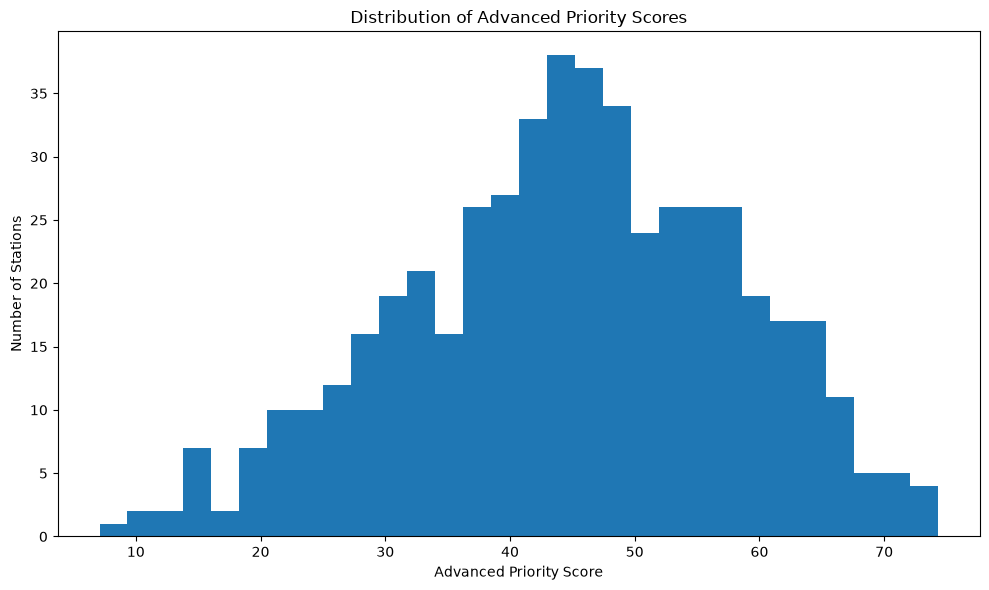

Priority distribution plot saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\advanced_priority_distribution.png


In [19]:
PRIORITY_DISTRIBUTION_PLOT_PATH = OUTPUTS_DIR / "advanced_priority_distribution.png"

plt.figure(figsize=(10, 6))
plt.hist(
    advanced_df["advanced_priority_score"].dropna(),
    bins=30
)
plt.xlabel("Advanced Priority Score")
plt.ylabel("Number of Stations")
plt.title("Distribution of Advanced Priority Scores")
plt.tight_layout()
plt.savefig(PRIORITY_DISTRIBUTION_PLOT_PATH, dpi=200)
plt.show()

print("Priority distribution plot saved:")
print(PRIORITY_DISTRIBUTION_PLOT_PATH)

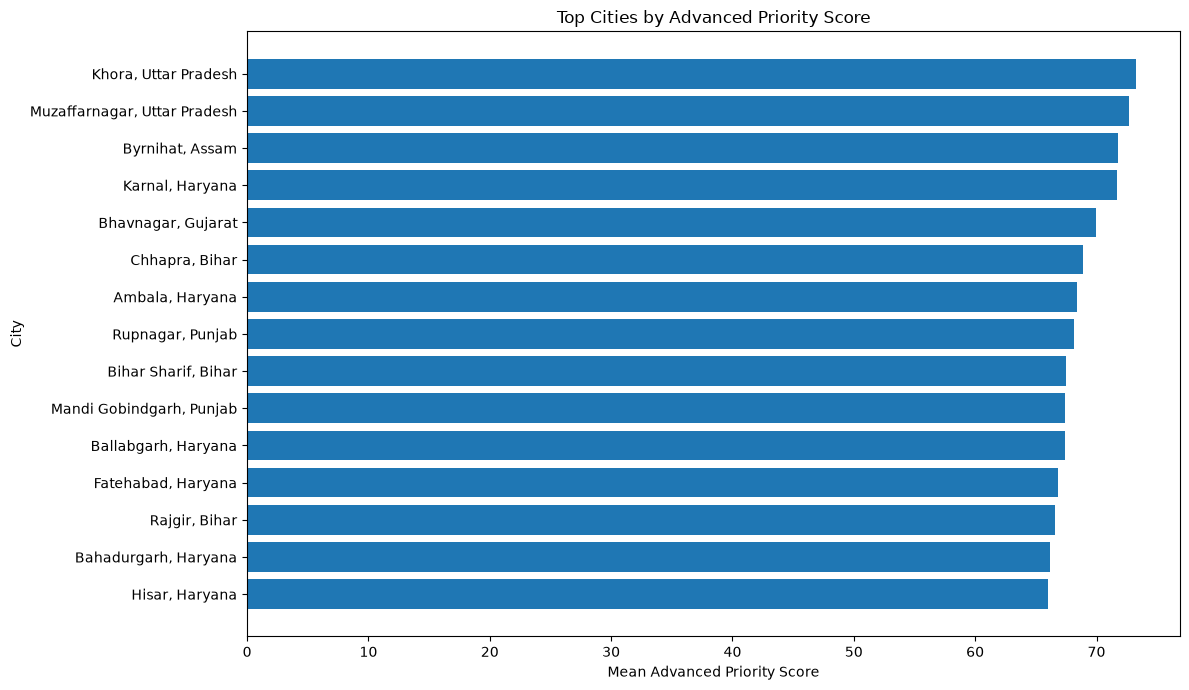

Top cities priority plot saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\top_cities_by_advanced_priority.png


In [20]:
TOP_CITIES_PLOT_PATH = OUTPUTS_DIR / "top_cities_by_advanced_priority.png"

top_cities_plot_df = city_advanced_summary.head(15).copy()

top_cities_plot_df["city_label"] = (
    top_cities_plot_df["city"].astype(str)
    + ", "
    + top_cities_plot_df["state"].astype(str)
)

plt.figure(figsize=(12, 7))
plt.barh(
    top_cities_plot_df["city_label"][::-1],
    top_cities_plot_df["mean_priority_score"][::-1]
)
plt.xlabel("Mean Advanced Priority Score")
plt.ylabel("City")
plt.title("Top Cities by Advanced Priority Score")
plt.tight_layout()
plt.savefig(TOP_CITIES_PLOT_PATH, dpi=200)
plt.show()

print("Top cities priority plot saved:")
print(TOP_CITIES_PLOT_PATH)


In [26]:
lat_column = find_first_existing_column(
    advanced_df,
    [
        "lat",
        "latitude"
    ]
)

lon_column = find_first_existing_column(
    advanced_df,
    [
        "lon",
        "lng",
        "longitude"
    ]
)

map_columns = [
    "advanced_priority_rank",
    "state",
    "city",
    "station_name",
    "current_aqi",
    "current_aqi_category",
    "forecast_aqi_next",
    "forecast_aqi_category",
    "forecast_aqi_change",
    "forecast_trend",
    "hotspot_status",
    "advanced_priority_score",
    "advanced_priority_category",
    "health_exposure_risk_score",
    "dispersion_index",
    "satellite_aerosol_proxy_score",
    "primary_pollution_source",
    "recommended_intervention",
    lat_column,
    lon_column
]

map_columns = [
    col for col in map_columns
    if col is not None and col in advanced_df.columns
]

map_ready_df = advanced_df[map_columns].copy()

if lat_column is not None:
    map_ready_df = map_ready_df.rename(columns={lat_column: "lat"})

if lon_column is not None:
    map_ready_df = map_ready_df.rename(columns={lon_column: "lon"})

MAP_READY_OUTPUT_PATH = OUTPUTS_DIR / "map_ready_advanced_hotspots.csv"

map_ready_df.to_csv(MAP_READY_OUTPUT_PATH, index=False)

print("Map-ready data saved:")
print(MAP_READY_OUTPUT_PATH)

display(map_ready_df.head())

Map-ready data saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\map_ready_advanced_hotspots.csv


,advanced_priority_rank,state,city,station_name,current_aqi,current_aqi_category,forecast_aqi_next,forecast_aqi_category,forecast_aqi_change,forecast_trend,hotspot_status,advanced_priority_score,advanced_priority_category,health_exposure_risk_score,dispersion_index,satellite_aerosol_proxy_score,primary_pollution_source,recommended_intervention,lat,lon
0,1,Uttar Pradesh,Meerut,"MIET College, Meerut - UPPCB",462.64,Severe,475.634843,Severe,12.994843,Stable,Critical forecast hotspot,74.32,High,88.17,50.36,65.56,Biomass / fine-particle combustion,"Immediate intervention: Track open burning, co...",28.972677,77.641018
1,2,Assam,Guwahati,"Pan Bazaar, Guwahati - PCBA",350.88,Very Poor,350.880000,Very Poor,0.000000,Stable,Critical forecast hotspot,74.19,High,76.07,94.26,60.25,Biomass / fine-particle combustion,"Immediate intervention: Track open burning, co...",26.187500,91.744194
2,3,Uttar Pradesh,Khora,"Prashant Garden, Khora - UPPCB",500.00,Severe,488.821643,Severe,-11.178357,Stable,Critical forecast hotspot,73.22,High,89.84,38.45,68.20,Biomass / fine-particle combustion,"Immediate intervention: Track open burning, co...",28.611190,77.342060
3,4,Uttar Pradesh,Muzaffarnagar,"New Mandi, Muzaffarnagar - UPPCB",462.64,Severe,491.163490,Severe,28.523490,Increasing,Critical forecast hotspot,72.69,High,80.41,65.87,49.64,Biomass / fine-particle combustion,"Immediate intervention: Track open burning, co...",29.472351,77.719403
4,5,Uttar Pradesh,Raebareli,"Anand Nagar, Raebareli - UPPCB",500.00,Severe,499.999446,Severe,-0.000554,Stable,Critical forecast hotspot,71.94,High,77.77,70.82,43.89,Biomass / fine-particle combustion,"Immediate intervention: Track open burning, co...",26.219512,81.237648


In [27]:
import sys
import subprocess
import importlib.util

package_name = "folium"

if importlib.util.find_spec(package_name) is None:
    print("Folium not found. Installing folium...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "folium"
    ])

    print("Folium installed successfully.")
else:
    print("Folium is already installed.")

import folium
from folium.plugins import MarkerCluster

print("Folium imported successfully.")

Folium not found. Installing folium...
Folium installed successfully.
Folium imported successfully.


In [28]:
HOTSPOT_MAP_PATH = OUTPUTS_DIR / "cleanair_advanced_hotspot_map.html"

try:
    import folium
    from folium.plugins import MarkerCluster

    map_df = map_ready_df.dropna(subset=["lat", "lon"]).copy()

    if len(map_df) == 0:
        print("No valid lat/lon rows available for map.")
        map_created = False

    else:
        center_lat = map_df["lat"].mean()
        center_lon = map_df["lon"].mean()

        hotspot_map = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=5,
            tiles="OpenStreetMap"
        )

        marker_cluster = MarkerCluster().add_to(hotspot_map)

        def marker_color(category):
            category = str(category).lower()

            if "critical" in category:
                return "red"
            elif "high" in category:
                return "orange"
            elif "moderate" in category:
                return "blue"
            elif "low" in category:
                return "green"
            else:
                return "gray"

        for _, row in map_df.iterrows():
            popup_text = f"""
            <b>{row.get('station_name', 'Unknown Station')}</b><br>
            City: {row.get('city', 'Unknown')}<br>
            State: {row.get('state', 'Unknown')}<br>
            Current AQI: {row.get('current_aqi', 'NA')}<br>
            Forecast AQI: {row.get('forecast_aqi_next', 'NA')}<br>
            Hotspot Status: {row.get('hotspot_status', 'NA')}<br>
            Priority Score: {row.get('advanced_priority_score', 'NA')}<br>
            Priority Rank: {row.get('advanced_priority_rank', 'NA')}<br>
            Source: {row.get('primary_pollution_source', 'NA')}<br>
            Recommendation: {row.get('recommended_intervention', 'NA')}
            """

            folium.CircleMarker(
                location=[
                    row["lat"],
                    row["lon"]
                ],
                radius=6,
                popup=folium.Popup(popup_text, max_width=450),
                color=marker_color(row.get("advanced_priority_category")),
                fill=True,
                fill_opacity=0.7
            ).add_to(marker_cluster)

        hotspot_map.save(HOTSPOT_MAP_PATH)

        print("Interactive hotspot map saved:")
        print(HOTSPOT_MAP_PATH)

        map_created = True

except ModuleNotFoundError:
    print("Folium is not installed.")
    print("Install it using: pip install folium")
    print("Continuing without interactive map.")

    map_created = False

except Exception as exc:
    print("Folium map could not be created.")
    print("Reason:", exc)

    map_created = False

Interactive hotspot map saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\cleanair_advanced_hotspot_map.html


In [29]:
source_distribution = {}

if "primary_pollution_source" in advanced_df.columns:
    source_distribution = (
        advanced_df["primary_pollution_source"]
        .value_counts(dropna=False)
        .to_dict()
    )

hotspot_distribution = (
    advanced_df["hotspot_status"]
    .value_counts(dropna=False)
    .to_dict()
)

priority_category_distribution = (
    advanced_df["advanced_priority_category"]
    .value_counts(dropna=False)
    .to_dict()
)

run_summary = {
    "notebook": "05_advanced_intelligence_layers.ipynb",
    "run_time": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "input_station_file": str(SOURCE_ATTRIBUTED_PATH),
    "input_predictions_file": str(PREDICTIONS_PATH),
    "best_forecasting_model": model_metrics.get("best_model"),
    "forecasting_best_metrics": model_metrics.get("best_metrics"),
    "station_rows": int(len(advanced_df)),
    "city_rows": int(len(city_advanced_summary)),
    "unique_stations": int(advanced_df["station_id"].nunique()) if "station_id" in advanced_df.columns else None,
    "unique_cities": int(advanced_df["city"].nunique()) if "city" in advanced_df.columns else None,
    "unique_states": int(advanced_df["state"].nunique()) if "state" in advanced_df.columns else None,
    "hotspot_distribution": hotspot_distribution,
    "priority_category_distribution": priority_category_distribution,
    "source_distribution": source_distribution,
    "top_priority_city": city_advanced_summary.iloc[0]["city"] if len(city_advanced_summary) > 0 else None,
    "top_priority_state": city_advanced_summary.iloc[0]["state"] if len(city_advanced_summary) > 0 else None,
    "station_advanced_output_file": str(STATION_ADVANCED_OUTPUT_PATH),
    "city_advanced_output_file": str(CITY_ADVANCED_OUTPUT_PATH),
    "top_hotspots_file": str(TOP_HOTSPOTS_OUTPUT_PATH),
    "map_ready_file": str(MAP_READY_OUTPUT_PATH),
    "priority_distribution_plot": str(PRIORITY_DISTRIBUTION_PLOT_PATH),
    "top_cities_plot": str(TOP_CITIES_PLOT_PATH),
    "interactive_map_file": str(HOTSPOT_MAP_PATH) if map_created else None,
    "note": (
        "Satellite aerosol score is a proxy score derived from pollutant and weather signals, "
        "not direct satellite imagery."
    )
}

NOTEBOOK_05_SUMMARY_PATH = REPORTS_DIR / "notebook_05_run_summary.json"

with open(NOTEBOOK_05_SUMMARY_PATH, "w", encoding="utf-8") as file:
    json.dump(run_summary, file, indent=4)

print("Notebook 05 run summary saved:")
print(NOTEBOOK_05_SUMMARY_PATH)

print(json.dumps(run_summary, indent=4))

Notebook 05 run summary saved:
C:\Users\Lenovo\Desktop\CleanAir_AI\reports\notebook_05_run_summary.json
{
    "notebook": "05_advanced_intelligence_layers.ipynb",
    "run_time": "2026-07-16 11:09:54",
    "input_station_file": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\data\\processed\\station_source_attributed.csv",
    "input_predictions_file": "C:\\Users\\Lenovo\\Desktop\\CleanAir_AI\\data\\processed\\test_predictions_with_uncertainty.csv",
    "best_forecasting_model": "Random Forest",
    "forecasting_best_metrics": {
        "model": "Random Forest",
        "mae": 14.5002,
        "rmse": 39.879,
        "r2": 0.8718,
        "improvement_over_persistence_percent": 4.22
    },
    "station_rows": 500,
    "city_rows": 266,
    "unique_stations": 500,
    "unique_cities": 264,
    "unique_states": 29,
    "hotspot_distribution": {
        "Critical forecast hotspot": 346,
        "High forecast hotspot": 76,
        "Watchlist": 66,
        "High current hotspot": 5,
        "Cri

In [30]:
required_output_files = [
    STATION_ADVANCED_OUTPUT_PATH,
    CITY_ADVANCED_OUTPUT_PATH,
    TOP_HOTSPOTS_OUTPUT_PATH,
    MAP_READY_OUTPUT_PATH,
    PRIORITY_DISTRIBUTION_PLOT_PATH,
    TOP_CITIES_PLOT_PATH,
    NOTEBOOK_05_SUMMARY_PATH
]

if map_created:
    required_output_files.append(HOTSPOT_MAP_PATH)

missing_files = [
    path for path in required_output_files
    if not Path(path).exists()
]

if missing_files:
    print("Missing files:")

    for path in missing_files:
        print(path)

    raise FileNotFoundError("Some expected Notebook 05 output files were not created.")

print("Notebook 05 completed successfully.")
print("Created files:")

for path in required_output_files:
    print("-", path)

Notebook 05 completed successfully.
Created files:
- C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\station_advanced_intelligence.csv
- C:\Users\Lenovo\Desktop\CleanAir_AI\data\processed\city_advanced_intelligence_summary.csv
- C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\top_priority_hotspots.csv
- C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\map_ready_advanced_hotspots.csv
- C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\advanced_priority_distribution.png
- C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\top_cities_by_advanced_priority.png
- C:\Users\Lenovo\Desktop\CleanAir_AI\reports\notebook_05_run_summary.json
- C:\Users\Lenovo\Desktop\CleanAir_AI\outputs\cleanair_advanced_hotspot_map.html
